# 08 — Full Uncertainty-Source Sensitivity
## PV-only, Wind-only, Load-only, and Combined uncertainty

This notebook performs the **full source-attribution experiment** using all four strategies:

- deterministic day-ahead scheduling (DET),
- two-stage stochastic day-ahead scheduling (STO),
- rolling-horizon MPC with the frozen feasibility-safe soft terminal anchor,
- perfect foresight (PF).

The source-specific experiments activate forecast error in exactly one source at a time:

\[
q\in\{\text{PV-only},\text{Wind-only},\text{Load-only}\},
\]

while all inactive sources are treated as perfectly forecasted. The already frozen **Combined** OOS results are reused rather than recomputed.

The new single-source OOS design contains

\[
127\times4\times2\times3=3048
\]

daily cases per strategy.

Scientific controls:
1. Same 127 held-out days.
2. Same point-forecast random stream; inactive sources are masked after the draws are generated.
3. \(N_0=5000\), \(K=50\), and \(H_p=6\) h remain frozen.
4. One common 24-dimensional BRA template is shared by PV-only, Wind-only, and Load-only STO cases.
5. Strict PF is reused because PF is source-independent.
6. Combined results are reused from the already validated main experiment.

In [5]:
from pathlib import Path
import json
import heapq
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.distance import cdist
import pyomo.environ as pyo

ROOT = Path.cwd()

def find_file(filename):
    candidates = [
        ROOT / filename,
        ROOT / "data" / filename,
        ROOT / "config" / filename,
        Path("/mnt/data") / filename,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not locate {filename}. Tried: {candidates}")

OOS_FILE = find_file("rye_oos_127days.csv")
DEV_FILE = find_file("rye_development_304days.csv")

PARAM_FILE = None
for pname in (
    "study_parameters_frozen_v10.json",
    "study_parameters_frozen_v9.json",
    "study_parameters_frozen_v8.json",
):
    try:
        PARAM_FILE = find_file(pname)
        break
    except FileNotFoundError:
        pass

if PARAM_FILE is None:
    raise FileNotFoundError("Could not locate the frozen study-parameter JSON.")

COMBINED_FILE = None
for fname in (
    "final_oos_det_sto_mpc_pf_daily.csv",
    "final_oos_det_sto_mpc_pf_daily_CORRECTED.csv",
):
    try:
        COMBINED_FILE = find_file(fname)
        break
    except FileNotFoundError:
        pass

if COMBINED_FILE is None:
    raise FileNotFoundError(
        "Place final_oos_det_sto_mpc_pf_daily.csv beside this notebook."
    )

oos = pd.read_csv(OOS_FILE)
dev = pd.read_csv(DEV_FILE)
combined_daily = pd.read_csv(COMBINED_FILE)

with open(PARAM_FILE, "r", encoding="utf-8") as f:
    CFG = json.load(f)

print("Development days:", dev["date_utc"].nunique())
print("OOS days:", oos["date_utc"].nunique())
print("Combined rows:", len(combined_daily))
print("Parameter file:", PARAM_FILE)
print("Combined file:", COMBINED_FILE)

assert dev["date_utc"].nunique() == 304
assert oos["date_utc"].nunique() == 127
assert len(combined_daily) == 1016

Development days: 304
OOS days: 127
Combined rows: 1016
Parameter file: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Source_Sensitivity_FULL\config\study_parameters_frozen_v10.json
Combined file: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Source_Sensitivity_FULL\final_oos_det_sto_mpc_pf_daily.csv


In [21]:
T = CFG["time"]["T_hours"]
DT = CFG["time"]["delta_t_h"]

PV_RATED = CFG["rye_physical_system"]["pv_rated_kwp"]
WIND_RATED = CFG["rye_physical_system"]["wind_rated_kw"]
BESS_E = CFG["rye_physical_system"]["bess_energy_kwh"]
P_CH_MAX = CFG["rye_physical_system"]["bess_charge_max_kw"]
P_DIS_MAX = CFG["rye_physical_system"]["bess_discharge_max_kw"]
ETA_CH = CFG["rye_physical_system"]["eta_charge"]
ETA_DIS = CFG["rye_physical_system"]["eta_discharge"]

SOC_MIN = CFG["bess_study_settings"]["soc_min"]
SOC_MAX = CFG["bess_study_settings"]["soc_max"]
SOC_INIT = CFG["bess_study_settings"]["soc_initial"]
SOC_TERM = CFG["bess_study_settings"]["soc_terminal"]

DG_MIN = CFG["study_added_diesel_generator"]["p_min_kw"]
DG_MAX = CFG["study_added_diesel_generator"]["p_max_kw"]
C_DG = CFG["study_added_diesel_generator"]["marginal_cost_nok_per_kwh"]

GRID_IMPORT_MAX = CFG["grid"]["import_max_kw"]
GRID_EXPORT_MAX = CFG["grid"]["export_max_kw"]
GRID_TARIFF = CFG["grid"]["energy_tariff_nok_per_kwh"]
SELL_FACTOR = CFG["grid"]["sell_price_fraction_of_buy"]

CRIT_SHARE = CFG["load_priority"]["critical_fraction"]
NCRIT_SHARE = CFG["load_priority"]["noncritical_fraction"]

C_BATT = CFG["objective_coefficients"]["battery_throughput_nok_per_kwh"]
C_CURT = CFG["objective_coefficients"]["renewable_curtailment_nok_per_kwh"]
C_SHED_N = CFG["objective_coefficients"]["noncritical_shedding_penalty_nok_per_kwh"]
C_SHED_C = CFG["objective_coefficients"]["critical_shedding_penalty_nok_per_kwh"]

ALPHAS = [float(x) for x in CFG["uncertainty"]["alpha_levels"]]
N0 = int(CFG["uncertainty"]["initial_monte_carlo_scenarios"])
K_FINAL = int(CFG["uncertainty"].get("final_reduced_scenarios", 50))
BASE_SEED = int(CFG["uncertainty"]["random_seed"])
CONFIDENCE = float(CFG["evaluation"]["confidence_level"])

HP_MAIN = int(CFG.get("mpc", {}).get("main_prediction_horizon_h", 6))
TERMINAL_SOC_PENALTY_NOK_PER_KWH = float(
    CFG.get("mpc", {}).get("terminal_soft_penalty_nok_per_kwh", 1000.0)
)
TERMINAL_SOC_REVIEW_BAND = float(
    CFG.get("mpc", {}).get("terminal_soc_review_band_absolute", 0.01)
)

MAIN_MIP_REL_GAP = float(CFG["solver"].get("main_mip_rel_gap", 1e-6))
MAIN_MIP_ABS_GAP = float(CFG["solver"].get("main_mip_abs_gap", 1e-7))

SOURCE_CASES = [
    "PV-only",
    "Wind-only",
    "Load-only",
    "Combined"
]

ALL_SOURCE_LABELS = SOURCE_CASES.copy()

assert N0 == 5000
assert K_FINAL == 50
assert HP_MAIN == 6

print("N0 =", N0, "| K =", K_FINAL, "| Hp =", HP_MAIN)
print("Sources:", SOURCE_CASES)
print("Alphas:", ALPHAS)

N0 = 5000 | K = 50 | Hp = 6
Sources: ['PV-only', 'Wind-only', 'Load-only', 'Combined']
Alphas: [0.05, 0.1, 0.2, 0.3]


In [22]:
print("Sources:", SOURCE_CASES)

Sources: ['PV-only', 'Wind-only', 'Load-only', 'Combined']


In [7]:
def get_day(df, date_string):
    x = df[df["date_utc"].astype(str) == str(date_string)].copy()
    x = x.sort_values("hour_utc")
    if len(x) != 24:
        raise ValueError(f"{date_string}: expected 24 rows, got {len(x)}")

    day = pd.DataFrame({
        "hour": np.arange(24),
        "pv": x["pv_clean_kw"].to_numpy(float),
        "wind": x["wind_clean_kw"].to_numpy(float),
        "load": x["load_kw"].to_numpy(float),
        "spot": x["spot_price_nok_per_kwh"].to_numpy(float),
    })
    day["buy_price"] = day["spot"] + GRID_TARIFF
    day["sell_price"] = SELL_FACTOR * day["buy_price"]
    day["load_crit"] = CRIT_SHARE * day["load"]
    day["load_ncrit"] = NCRIT_SHARE * day["load"]
    return day


def oos_forecast_seed(date_string, alpha, base_seed=BASE_SEED):
    date_num = int(str(date_string).replace("-", ""))
    alpha_num = int(round(float(alpha) * 1000))
    return (base_seed + date_num * 1009 + alpha_num * 9176) % (2**32 - 1)


def source_active(source, col):
    mapping = {
        "PV-only": "pv",
        "Wind-only": "wind",
        "Load-only": "load",
        "Combined": "all",
    }
    if source not in mapping:
        raise ValueError(f"Unknown source: {source}")
    return mapping[source] == "all" or mapping[source] == col


def make_source_forecast(actual, alpha, date_string, source):
    """
    Generate all three source-error streams in the same order as the frozen
    Combined baseline, then mask inactive sources back to the actual trajectory.
    """
    rng = np.random.default_rng(oos_forecast_seed(date_string, alpha))
    fc = actual.copy()

    for col, cap in [("pv", PV_RATED), ("wind", WIND_RATED), ("load", None)]:
        realized = actual[col].to_numpy(float)

        # Always consume the draw to preserve common random numbers.
        e = rng.normal(0.0, float(alpha), size=24)
        e = np.clip(e, -0.80, 1.50)

        if source_active(source, col):
            forecast = realized / (1.0 + e)
            forecast = np.maximum(forecast, 0.0)
            if cap is not None:
                forecast = np.minimum(forecast, cap)
        else:
            forecast = realized.copy()

        fc[col] = forecast

    fc["load_crit"] = CRIT_SHARE * fc["load"]
    fc["load_ncrit"] = NCRIT_SHARE * fc["load"]
    return fc


counts = oos.groupby("date_utc").size()
assert len(counts) == 127 and (counts == 24).all()

pf_spread = (
    combined_daily
    .groupby(["date", "mode"])["pf_cost_nok"]
    .agg(lambda x: float(np.max(x) - np.min(x)))
)
assert float(pf_spread.max()) <= 1e-8

print("Source forecast and PF integrity checks PASSED.")

Source forecast and PF integrity checks PASSED.


## Common single-source BRA template

The single-source stochastic vector has 24 dimensions. A common standardized
\(5000\times24\) normal pool is reduced once to \(K=50\) by BRA. The same reduced
errors and probabilities are then used for PV-only, Wind-only, and Load-only.

This creates a common-random-number source comparison while leaving the frozen
Combined experiment unchanged.

In [25]:
def bra_seed(*parts, base=BASE_SEED):
    value = int(base)
    for p in parts:
        for ch in str(p):
            value = (value * 131 + ord(ch)) % (2**32 - 1)
    return value


def backward_reduction_to_target(errors, probabilities, target_count):
    errors = np.asarray(errors, dtype=np.float32)
    probs = np.asarray(probabilities, dtype=np.float64).copy()
    n = len(probs)

    D = cdist(errors, errors, metric="euclidean").astype(np.float32)
    np.fill_diagonal(D, np.inf)

    active = np.ones(n, dtype=bool)
    version = np.zeros(n, dtype=np.int64)

    def nearest_active(i):
        work = D[i].copy()
        work[~active] = np.inf
        work[i] = np.inf
        j = int(np.argmin(work))
        return j, float(work[j])

    heap = []
    for i in range(n):
        _, d = nearest_active(i)
        heapq.heappush(heap, (probs[i] * d, i, version[i]))

    remaining = n
    while remaining > target_count:
        while True:
            old_cost, i, ver = heapq.heappop(heap)
            if not active[i] or ver != version[i]:
                continue

            j, d = nearest_active(i)
            true_cost = probs[i] * d
            if true_cost > old_cost + 1e-12:
                version[i] += 1
                heapq.heappush(heap, (true_cost, i, version[i]))
                continue
            break

        removed_prob = probs[i]
        active[i] = False
        probs[i] = 0.0
        remaining -= 1

        probs[j] += removed_prob
        version[j] += 1

        if remaining > 1:
            _, d2 = nearest_active(j)
            heapq.heappush(heap, (probs[j] * d2, j, version[j]))

    idx = np.where(active)[0]
    pr = probs[idx]
    pr = pr / pr.sum()
    return idx, pr


SINGLE_BRA_FILE = ROOT / f"bra_single_source_N{N0}_K{K_FINAL}.npz"

def load_or_build_single_source_bra():
    if SINGLE_BRA_FILE.exists():
        z = np.load(SINGLE_BRA_FILE)
        Z = z["z_standardized"].astype(float)
        probs = z["probability"].astype(float)
        probs = probs / probs.sum()
        print("Loaded:", SINGLE_BRA_FILE)
        return Z, probs

    print("Building common 24-D BRA template...")
    rng = np.random.default_rng(bra_seed("single_source_BRA"))
    errors = rng.normal(0.0, 1.0, size=(N0, 24)).astype(np.float32)
    probs = np.full(N0, 1.0 / N0, dtype=np.float64)

    idx, probs_red = backward_reduction_to_target(errors, probs, K_FINAL)
    Z = errors[idx].astype(float)

    np.savez_compressed(
        SINGLE_BRA_FILE,
        z_standardized=Z,
        probability=probs_red,
    )
    print("Saved:", SINGLE_BRA_FILE)
    return Z, probs_red


Z_SINGLE, SINGLE_BRA_PROBS = load_or_build_single_source_bra()

assert Z_SINGLE.shape == (K_FINAL, 24)
assert np.isclose(SINGLE_BRA_PROBS.sum(), 1.0, atol=1e-10)


def scenarios_from_source_forecast(forecast, alpha, source):
    z = float(alpha) * Z_SINGLE
    K = len(SINGLE_BRA_PROBS)

    base_pv = forecast["pv"].to_numpy(float)
    base_w = forecast["wind"].to_numpy(float)
    base_l = forecast["load"].to_numpy(float)

    pv = np.repeat(base_pv[None, :], K, axis=0)
    wind = np.repeat(base_w[None, :], K, axis=0)
    load = np.repeat(base_l[None, :], K, axis=0)

    if source == "PV-only":
        pv = np.clip(base_pv[None, :] * (1.0 + z), 0.0, PV_RATED)
    elif source == "Wind-only":
        wind = np.clip(base_w[None, :] * (1.0 + z), 0.0, WIND_RATED)
    elif source == "Load-only":
        load = np.maximum(base_l[None, :] * (1.0 + z), 0.0)
    
    elif source == "Combined":
    
        pv = np.clip(
            base_pv[None, :] * (1.0 + z),
            0.0,
            PV_RATED
        )
    
        wind = np.clip(
            base_w[None, :] * (1.0 + z),
            0.0,
            WIND_RATED
        )
    
        load = np.maximum(
            base_l[None, :] * (1.0 + z),
            0.0
        )
    
    else:
        raise ValueError(
            "Use PV-only, Wind-only, Load-only, or Combined."
        )

    return {"pv": pv, "wind": wind, "load": load}


print("Single-source BRA ready. K =", len(SINGLE_BRA_PROBS))

Loaded: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Source_Sensitivity_FULL\bra_single_source_N5000_K50.npz
Single-source BRA ready. K = 50


In [26]:
def configure_highs_solver(rel_gap=MAIN_MIP_REL_GAP, abs_gap=MAIN_MIP_ABS_GAP):
    for name in ("appsi_highs", "highs"):
        try:
            s = pyo.SolverFactory(name)
            if s is None or not s.available(exception_flag=False):
                continue

            if name == "appsi_highs":
                try:
                    s.config.mip_gap = rel_gap
                except Exception:
                    pass
                try:
                    s.highs_options["mip_rel_gap"] = rel_gap
                    s.highs_options["mip_abs_gap"] = abs_gap
                except Exception:
                    pass
            else:
                try:
                    s.options["mip_rel_gap"] = rel_gap
                    s.options["mip_abs_gap"] = abs_gap
                except Exception:
                    pass

            print(f"Using {name}: rel_gap={rel_gap:g}, abs_gap={abs_gap:g}")
            return s
        except Exception:
            pass

    raise RuntimeError("HiGHS not found. Install pyomo and highspy.")


solver = configure_highs_solver()


def solve_checked(model, tee=False):
    t0 = time.perf_counter()
    result = solver.solve(model, tee=tee)
    elapsed = time.perf_counter() - t0

    term = str(result.solver.termination_condition).lower()
    if "optimal" not in term:
        raise RuntimeError(f"Solver termination: {result.solver.termination_condition}")
    return elapsed

Using appsi_highs: rel_gap=1e-06, abs_gap=1e-07


In [27]:
def build_single_scenario_model(day, mode="GC", fixed_u=None, fixed_y=None):
    if mode not in {"GC", "IS"}:
        raise ValueError("mode must be GC or IS")

    g = 1 if mode == "GC" else 0

    m = pyo.ConcreteModel(name=f"Single_{mode}")
    m.T = pyo.RangeSet(0, 23)
    m.Tsoc = pyo.RangeSet(0, 24)

    m.pv_av = pyo.Param(
        m.T,
        initialize={t: float(day["pv"].iloc[t]) for t in range(24)},
        within=pyo.NonNegativeReals,
    )
    m.w_av = pyo.Param(
        m.T,
        initialize={t: float(day["wind"].iloc[t]) for t in range(24)},
        within=pyo.NonNegativeReals,
    )
    m.P_load = pyo.Param(
        m.T,
        initialize={t: float(day["load"].iloc[t]) for t in range(24)},
        within=pyo.NonNegativeReals,
    )
    m.cbuy = pyo.Param(
        m.T, initialize={t: float(day["buy_price"].iloc[t]) for t in range(24)}
    )
    m.csell = pyo.Param(
        m.T, initialize={t: float(day["sell_price"].iloc[t]) for t in range(24)}
    )

    m.u_dg = pyo.Var(m.T, domain=pyo.Binary)
    m.y_b = pyo.Var(m.T, domain=pyo.Binary)

    m.P_pv = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_w = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_dg = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_ch = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_dis = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.SOC = pyo.Var(m.Tsoc, bounds=(SOC_MIN, SOC_MAX))
    m.P_buy = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_sell = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.shed_c = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.shed_n = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.curt = pyo.Var(m.T, domain=pyo.NonNegativeReals)

    m.cost = pyo.Objective(
        expr=sum(
            (
                m.cbuy[t] * m.P_buy[t]
                - m.csell[t] * m.P_sell[t]
                + C_DG * m.P_dg[t]
                + C_BATT * (m.P_ch[t] + m.P_dis[t])
                + C_CURT * m.curt[t]
                + C_SHED_C * m.shed_c[t]
                + C_SHED_N * m.shed_n[t]
            ) * DT
            for t in m.T
        ),
        sense=pyo.minimize,
    )

    m.pvlim = pyo.Constraint(m.T, rule=lambda m,t: m.P_pv[t] <= m.pv_av[t])
    m.wlim = pyo.Constraint(m.T, rule=lambda m,t: m.P_w[t] <= m.w_av[t])
    m.curtdef = pyo.Constraint(
        m.T,
        rule=lambda m,t:
        m.curt[t] == (m.pv_av[t] - m.P_pv[t]) + (m.w_av[t] - m.P_w[t])
    )
    m.dgmin = pyo.Constraint(
        m.T, rule=lambda m,t: m.P_dg[t] >= DG_MIN * m.u_dg[t]
    )
    m.dgmax = pyo.Constraint(
        m.T, rule=lambda m,t: m.P_dg[t] <= DG_MAX * m.u_dg[t]
    )

    m.soc0 = pyo.Constraint(expr=m.SOC[0] == SOC_INIT)
    m.socterm = pyo.Constraint(expr=m.SOC[24] == SOC_TERM)
    m.socdyn = pyo.Constraint(
        m.T,
        rule=lambda m,t:
        m.SOC[t+1]
        == m.SOC[t]
        + ETA_CH * m.P_ch[t] * DT / BESS_E
        - m.P_dis[t] * DT / (ETA_DIS * BESS_E)
    )

    m.chlim = pyo.Constraint(
        m.T, rule=lambda m,t: m.P_ch[t] <= P_CH_MAX * m.y_b[t]
    )
    m.dislim = pyo.Constraint(
        m.T, rule=lambda m,t: m.P_dis[t] <= P_DIS_MAX * (1 - m.y_b[t])
    )

    m.shedclim = pyo.Constraint(
        m.T, rule=lambda m,t: m.shed_c[t] <= CRIT_SHARE * m.P_load[t]
    )
    m.shednlim = pyo.Constraint(
        m.T, rule=lambda m,t: m.shed_n[t] <= NCRIT_SHARE * m.P_load[t]
    )

    m.buylim = pyo.Constraint(
        m.T, rule=lambda m,t: m.P_buy[t] <= g * GRID_IMPORT_MAX
    )
    m.selllim = pyo.Constraint(
        m.T, rule=lambda m,t: m.P_sell[t] <= g * GRID_EXPORT_MAX
    )

    m.balance = pyo.Constraint(
        m.T,
        rule=lambda m,t:
        m.P_pv[t] + m.P_w[t] + m.P_dg[t] + m.P_dis[t] + m.P_buy[t]
        == m.P_load[t] - m.shed_c[t] - m.shed_n[t]
        + m.P_ch[t] + m.P_sell[t]
    )

    if fixed_u is not None:
        for t in range(24):
            m.u_dg[t].fix(int(round(float(fixed_u[t]))))
    if fixed_y is not None:
        for t in range(24):
            m.y_b[t].fix(int(round(float(fixed_y[t]))))

    return m

def single_model_metrics(model):
    shed_c = np.array([pyo.value(model.shed_c[t]) for t in model.T], dtype=float)
    shed_n = np.array([pyo.value(model.shed_n[t]) for t in model.T], dtype=float)
    buy = np.array([pyo.value(model.P_buy[t]) for t in model.T], dtype=float)
    sell = np.array([pyo.value(model.P_sell[t]) for t in model.T], dtype=float)
    dg = np.array([pyo.value(model.P_dg[t]) for t in model.T], dtype=float)
    curt = np.array([pyo.value(model.curt[t]) for t in model.T], dtype=float)

    return {
        "cost_nok": float(pyo.value(model.cost)),
        "critical_eens_kwh": float(shed_c.sum() * DT),
        "noncritical_eens_kwh": float(shed_n.sum() * DT),
        "critical_interrupted": int((shed_c.sum() * DT) > 1e-6),
        "diesel_energy_kwh": float(dg.sum() * DT),
        "curtailment_kwh": float(curt.sum() * DT),
        "grid_import_kwh": float(buy.sum() * DT),
        "grid_export_kwh": float(sell.sum() * DT),
        "terminal_soc": float(pyo.value(model.SOC[24])),
        "max_simultaneous_buy_sell_kw": float(np.max(np.minimum(buy, sell))),
    }

In [28]:
def build_sto_model(forecast, scenarios, probs, mode="GC"):
    if mode not in {"GC", "IS"}:
        raise ValueError("mode must be GC or IS")

    K = len(probs)
    g = 1 if mode == "GC" else 0

    m = pyo.ConcreteModel(name=f"STO_{mode}_K{K}")
    m.T = pyo.RangeSet(0, 23)
    m.S = pyo.RangeSet(0, K-1)
    m.Tsoc = pyo.RangeSet(0, 24)

    m.pi = pyo.Param(m.S, initialize={s: float(probs[s]) for s in range(K)})

    m.pv_av = pyo.Param(
        m.S, m.T,
        initialize={(s,t): float(scenarios["pv"][s,t]) for s in range(K) for t in range(24)},
        within=pyo.NonNegativeReals,
    )
    m.w_av = pyo.Param(
        m.S, m.T,
        initialize={(s,t): float(scenarios["wind"][s,t]) for s in range(K) for t in range(24)},
        within=pyo.NonNegativeReals,
    )
    m.P_load = pyo.Param(
        m.S, m.T,
        initialize={(s,t): float(scenarios["load"][s,t]) for s in range(K) for t in range(24)},
        within=pyo.NonNegativeReals,
    )
    m.cbuy = pyo.Param(
        m.T, initialize={t: float(forecast["buy_price"].iloc[t]) for t in range(24)}
    )
    m.csell = pyo.Param(
        m.T, initialize={t: float(forecast["sell_price"].iloc[t]) for t in range(24)}
    )

    m.u_dg = pyo.Var(m.T, domain=pyo.Binary)
    m.y_b = pyo.Var(m.T, domain=pyo.Binary)

    m.P_pv = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.P_w = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.P_dg = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.P_ch = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.P_dis = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.SOC = pyo.Var(m.S, m.Tsoc, bounds=(SOC_MIN, SOC_MAX))
    m.P_buy = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.P_sell = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.shed_c = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.shed_n = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.curt = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)

    m.cost = pyo.Objective(
        expr=sum(
            m.pi[s] * sum(
                (
                    m.cbuy[t] * m.P_buy[s,t]
                    - m.csell[t] * m.P_sell[s,t]
                    + C_DG * m.P_dg[s,t]
                    + C_BATT * (m.P_ch[s,t] + m.P_dis[s,t])
                    + C_CURT * m.curt[s,t]
                    + C_SHED_C * m.shed_c[s,t]
                    + C_SHED_N * m.shed_n[s,t]
                ) * DT
                for t in m.T
            )
            for s in m.S
        ),
        sense=pyo.minimize,
    )

    m.pvlim = pyo.Constraint(m.S,m.T,rule=lambda m,s,t: m.P_pv[s,t] <= m.pv_av[s,t])
    m.wlim = pyo.Constraint(m.S,m.T,rule=lambda m,s,t: m.P_w[s,t] <= m.w_av[s,t])
    m.curtdef = pyo.Constraint(
        m.S,m.T,
        rule=lambda m,s,t:
        m.curt[s,t] == (m.pv_av[s,t] - m.P_pv[s,t]) + (m.w_av[s,t] - m.P_w[s,t])
    )
    m.dgmin = pyo.Constraint(
        m.S,m.T,rule=lambda m,s,t: m.P_dg[s,t] >= DG_MIN * m.u_dg[t]
    )
    m.dgmax = pyo.Constraint(
        m.S,m.T,rule=lambda m,s,t: m.P_dg[s,t] <= DG_MAX * m.u_dg[t]
    )

    m.soc0 = pyo.Constraint(m.S,rule=lambda m,s: m.SOC[s,0] == SOC_INIT)
    m.socterm = pyo.Constraint(m.S,rule=lambda m,s: m.SOC[s,24] == SOC_TERM)
    m.socdyn = pyo.Constraint(
        m.S,m.T,
        rule=lambda m,s,t:
        m.SOC[s,t+1]
        == m.SOC[s,t]
        + ETA_CH * m.P_ch[s,t] * DT / BESS_E
        - m.P_dis[s,t] * DT / (ETA_DIS * BESS_E)
    )
    m.chlim = pyo.Constraint(
        m.S,m.T,rule=lambda m,s,t: m.P_ch[s,t] <= P_CH_MAX * m.y_b[t]
    )
    m.dislim = pyo.Constraint(
        m.S,m.T,rule=lambda m,s,t: m.P_dis[s,t] <= P_DIS_MAX * (1 - m.y_b[t])
    )
    m.shedclim = pyo.Constraint(
        m.S,m.T,rule=lambda m,s,t: m.shed_c[s,t] <= CRIT_SHARE * m.P_load[s,t]
    )
    m.shednlim = pyo.Constraint(
        m.S,m.T,rule=lambda m,s,t: m.shed_n[s,t] <= NCRIT_SHARE * m.P_load[s,t]
    )
    m.buylim = pyo.Constraint(
        m.S,m.T,rule=lambda m,s,t: m.P_buy[s,t] <= g * GRID_IMPORT_MAX
    )
    m.selllim = pyo.Constraint(
        m.S,m.T,rule=lambda m,s,t: m.P_sell[s,t] <= g * GRID_EXPORT_MAX
    )
    m.balance = pyo.Constraint(
        m.S,m.T,
        rule=lambda m,s,t:
        m.P_pv[s,t] + m.P_w[s,t] + m.P_dg[s,t] + m.P_dis[s,t] + m.P_buy[s,t]
        == m.P_load[s,t] - m.shed_c[s,t] - m.shed_n[s,t]
        + m.P_ch[s,t] + m.P_sell[s,t]
    )
    return m

In [29]:
def extract_first_stage(model):
    u = np.array([pyo.value(model.u_dg[t]) for t in model.T], dtype=float)
    y = np.array([pyo.value(model.y_b[t]) for t in model.T], dtype=float)
    return u, y


def run_det_source_day(actual, forecast, mode):
    da = build_single_scenario_model(forecast, mode=mode)
    t_da = solve_checked(da)
    u, y = extract_first_stage(da)

    real = build_single_scenario_model(actual, mode=mode, fixed_u=u, fixed_y=y)
    t_real = solve_checked(real)

    return {
        "metrics": single_model_metrics(real),
        "solve_time_s": t_da + t_real,
    }


def run_sto_source_day(actual, forecast, alpha, source, mode):
    scen = scenarios_from_source_forecast(forecast, alpha, source)
    sto = build_sto_model(forecast, scen, SINGLE_BRA_PROBS, mode=mode)
    t_sto = solve_checked(sto)
    u, y = extract_first_stage(sto)

    real = build_single_scenario_model(actual, mode=mode, fixed_u=u, fixed_y=y)
    t_real = solve_checked(real)

    return {
        "metrics": single_model_metrics(real),
        "sto_solve_time_s": t_sto,
        "recourse_solve_time_s": t_real,
    }


pf_cols = [
    "date", "mode", "pf_cost_nok",
    "pf_critical_eens_kwh", "pf_noncritical_eens_kwh",
]
if "pf_critical_interrupted" in combined_daily.columns:
    pf_cols.append("pf_critical_interrupted")

pf_lookup = (
    combined_daily[pf_cols]
    .drop_duplicates(subset=["date", "mode"])
    .copy()
)

if "pf_critical_interrupted" not in pf_lookup.columns:
    pf_lookup["pf_critical_interrupted"] = (
        pf_lookup["pf_critical_eens_kwh"] > 1e-6
    ).astype(int)

assert len(pf_lookup) == 254

PF_DICT = {
    (str(r.date), str(r.mode)): r
    for r in pf_lookup.itertuples(index=False)
}


SOURCE_DET_STO_CHECKPOINT = ROOT / "source_sensitivity_det_sto_checkpoint.csv"
SOURCE_DET_STO_FILE = ROOT / "source_sensitivity_det_sto_daily.csv"


def completed_source_keys(df):
    if df is None or len(df) == 0:
        return set()
    return set(zip(
        df["date"].astype(str),
        df["source"].astype(str),
        df["alpha"].astype(float),
        df["mode"].astype(str),
    ))


def run_source_det_sto_oos(
    oos_df,
    sources=SOURCE_CASES,
    alphas=ALPHAS,
    modes=("GC", "IS"),
):
    dates = sorted(oos_df["date_utc"].astype(str).unique())
    total = len(dates) * len(sources) * len(alphas) * len(modes)

    if SOURCE_DET_STO_CHECKPOINT.exists():
        out = pd.read_csv(SOURCE_DET_STO_CHECKPOINT)
        done = completed_source_keys(out)
        print(f"Resuming DET/STO checkpoint with {len(out)} cases.")
    else:
        out = pd.DataFrame()
        done = set()

    new_rows = []

    for day_i, date in enumerate(dates, start=1):
        actual = get_day(oos_df, date)

        for source in sources:
            for alpha in alphas:
                forecast = make_source_forecast(actual, alpha, date, source)

                for mode in modes:
                    key = (date, source, float(alpha), mode)
                    if key in done:
                        continue

                    try:
                        det = run_det_source_day(actual, forecast, mode)
                        sto = run_sto_source_day(actual, forecast, alpha, source, mode)
                    except Exception:
                        print(
                            f"FAILED DET/STO: date={date}, source={source}, "
                            f"alpha={alpha}, mode={mode}"
                        )
                        raise

                    pf = PF_DICT[(date, mode)]
                    dm = det["metrics"]
                    sm = sto["metrics"]

                    new_rows.append({
                        "date": date,
                        "source": source,
                        "mode": mode,
                        "alpha": float(alpha),

                        "det_cost_nok": dm["cost_nok"],
                        "sto_cost_nok": sm["cost_nok"],
                        "pf_cost_nok": float(pf.pf_cost_nok),

                        "det_critical_eens_kwh": dm["critical_eens_kwh"],
                        "sto_critical_eens_kwh": sm["critical_eens_kwh"],
                        "pf_critical_eens_kwh": float(pf.pf_critical_eens_kwh),

                        "det_noncritical_eens_kwh": dm["noncritical_eens_kwh"],
                        "sto_noncritical_eens_kwh": sm["noncritical_eens_kwh"],
                        "pf_noncritical_eens_kwh": float(pf.pf_noncritical_eens_kwh),

                        "det_critical_interrupted": dm["critical_interrupted"],
                        "sto_critical_interrupted": sm["critical_interrupted"],
                        "pf_critical_interrupted": int(pf.pf_critical_interrupted),

                        "det_diesel_kwh": dm["diesel_energy_kwh"],
                        "sto_diesel_kwh": sm["diesel_energy_kwh"],
                        "det_curtailment_kwh": dm["curtailment_kwh"],
                        "sto_curtailment_kwh": sm["curtailment_kwh"],
                        "det_grid_import_kwh": dm["grid_import_kwh"],
                        "sto_grid_import_kwh": sm["grid_import_kwh"],
                        "det_grid_export_kwh": dm["grid_export_kwh"],
                        "sto_grid_export_kwh": sm["grid_export_kwh"],

                        "det_solve_time_s": det["solve_time_s"],
                        "sto_solve_time_s": sto["sto_solve_time_s"],
                        "sto_recourse_time_s": sto["recourse_solve_time_s"],

                        "det_max_simultaneous_buy_sell_kw": dm["max_simultaneous_buy_sell_kw"],
                        "sto_max_simultaneous_buy_sell_kw": sm["max_simultaneous_buy_sell_kw"],
                    })
                    done.add(key)

        if new_rows:
            add = pd.DataFrame(new_rows)
            out = pd.concat([out, add], ignore_index=True)
            new_rows = []
            out = out.sort_values(
                ["date", "source", "alpha", "mode"]
            ).reset_index(drop=True)
            out.to_csv(SOURCE_DET_STO_CHECKPOINT, index=False)

        print(
            f"DET/STO source sensitivity completed {day_i}/{len(dates)} days "
            f"({len(out)}/{total} cases saved)"
        )

    out.to_csv(SOURCE_DET_STO_FILE, index=False)
    print("DET/STO source file saved:", SOURCE_DET_STO_FILE)
    return out

## Source-specific rolling MPC

The current hour is exact. Future errors use

\[
\sigma_k=\alpha\sqrt{k/24}.
\]

All three source random draws are still consumed in the same order as the frozen
Combined MPC experiment; only the selected source is actually perturbed.

In [30]:
def mpc_seed(date_string, alpha, current_hour, base_seed=BASE_SEED):
    date_num = int(str(date_string).replace("-", ""))
    alpha_num = int(round(float(alpha) * 1000))
    return (
        int(base_seed)
        + date_num * 1009
        + alpha_num * 9176
        + int(current_hour) * 7919
    ) % (2**32 - 1)


def build_mpc_source_forecast_horizon(
    actual_day,
    date_string,
    alpha,
    source,
    current_hour,
    hp,
):
    H = min(int(hp), 24 - int(current_hour))
    rng = np.random.default_rng(mpc_seed(date_string, alpha, current_hour))

    out = actual_day.iloc[
        current_hour:current_hour + H
    ].copy().reset_index(drop=True)

    for col, cap in [("pv", PV_RATED), ("wind", WIND_RATED), ("load", None)]:
        realized = out[col].to_numpy(float)
        forecast = realized.copy()

        for k in range(1, H):
            sigma = float(alpha) * np.sqrt(k / 24.0)
            e = rng.normal(0.0, sigma)
            e = np.clip(e, -0.80, 1.50)

            if source_active(source, col):
                forecast[k] = realized[k] / (1.0 + e)
                forecast[k] = max(forecast[k], 0.0)
                if cap is not None:
                    forecast[k] = min(forecast[k], cap)
            else:
                forecast[k] = realized[k]

        out[col] = forecast

    return out

In [31]:
def build_mpc_model(
    horizon_df,
    mode,
    current_soc,
    terminal_soc_target,
    soft_terminal=False,
    terminal_penalty_nok_per_kwh=TERMINAL_SOC_PENALTY_NOK_PER_KWH,
):
    if mode not in {"GC", "IS"}:
        raise ValueError("mode must be GC or IS")

    H = len(horizon_df)
    g = 1 if mode == "GC" else 0

    m = pyo.ConcreteModel(name=f"MPC_{mode}_H{H}")
    m.K = pyo.RangeSet(0, H - 1)
    m.Ksoc = pyo.RangeSet(0, H)

    m.pv_av = pyo.Param(
        m.K,
        initialize={k: float(horizon_df["pv"].iloc[k]) for k in range(H)},
        within=pyo.NonNegativeReals,
    )
    m.w_av = pyo.Param(
        m.K,
        initialize={k: float(horizon_df["wind"].iloc[k]) for k in range(H)},
        within=pyo.NonNegativeReals,
    )
    m.P_load = pyo.Param(
        m.K,
        initialize={k: float(horizon_df["load"].iloc[k]) for k in range(H)},
        within=pyo.NonNegativeReals,
    )
    m.cbuy = pyo.Param(
        m.K,
        initialize={k: float(horizon_df["buy_price"].iloc[k]) for k in range(H)},
    )
    m.csell = pyo.Param(
        m.K,
        initialize={k: float(horizon_df["sell_price"].iloc[k]) for k in range(H)},
    )

    m.u_dg = pyo.Var(m.K, domain=pyo.Binary)
    m.y_b = pyo.Var(m.K, domain=pyo.Binary)

    m.P_pv = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.P_w = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.P_dg = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.P_ch = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.P_dis = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.SOC = pyo.Var(m.Ksoc, bounds=(SOC_MIN, SOC_MAX))
    m.P_buy = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.P_sell = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.shed_c = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.shed_n = pyo.Var(m.K, domain=pyo.NonNegativeReals)
    m.curt = pyo.Var(m.K, domain=pyo.NonNegativeReals)

    operating_cost_expr = sum(
        (
            m.cbuy[k] * m.P_buy[k]
            - m.csell[k] * m.P_sell[k]
            + C_DG * m.P_dg[k]
            + C_BATT * (m.P_ch[k] + m.P_dis[k])
            + C_CURT * m.curt[k]
            + C_SHED_C * m.shed_c[k]
            + C_SHED_N * m.shed_n[k]
        ) * DT
        for k in m.K
    )
    m.operating_cost = pyo.Expression(expr=operating_cost_expr)

    m.soc0 = pyo.Constraint(expr=m.SOC[0] == float(current_soc))

    if soft_terminal:
        m.soc_dev_pos = pyo.Var(domain=pyo.NonNegativeReals)
        m.soc_dev_neg = pyo.Var(domain=pyo.NonNegativeReals)

        m.socterm = pyo.Constraint(
            expr=(
                m.SOC[H] - float(terminal_soc_target)
                == m.soc_dev_pos - m.soc_dev_neg
            )
        )

        # SOC is per unit, so multiply by BESS_E to obtain kWh deviation.
        m.terminal_penalty_cost = pyo.Expression(
            expr=(
                float(terminal_penalty_nok_per_kwh)
                * BESS_E
                * (m.soc_dev_pos + m.soc_dev_neg)
            )
        )
    else:
        m.socterm = pyo.Constraint(
            expr=m.SOC[H] == float(terminal_soc_target)
        )
        m.terminal_penalty_cost = pyo.Expression(expr=0.0)

    m.cost = pyo.Objective(
        expr=m.operating_cost + m.terminal_penalty_cost,
        sense=pyo.minimize,
    )

    m.pvlim = pyo.Constraint(
        m.K, rule=lambda m, k: m.P_pv[k] <= m.pv_av[k]
    )
    m.wlim = pyo.Constraint(
        m.K, rule=lambda m, k: m.P_w[k] <= m.w_av[k]
    )
    m.curtdef = pyo.Constraint(
        m.K,
        rule=lambda m, k:
            m.curt[k]
            == (m.pv_av[k] - m.P_pv[k])
            + (m.w_av[k] - m.P_w[k]),
    )

    m.dgmin = pyo.Constraint(
        m.K, rule=lambda m, k: m.P_dg[k] >= DG_MIN * m.u_dg[k]
    )
    m.dgmax = pyo.Constraint(
        m.K, rule=lambda m, k: m.P_dg[k] <= DG_MAX * m.u_dg[k]
    )

    m.socdyn = pyo.Constraint(
        m.K,
        rule=lambda m, k:
            m.SOC[k + 1]
            == m.SOC[k]
            + ETA_CH * m.P_ch[k] * DT / BESS_E
            - m.P_dis[k] * DT / (ETA_DIS * BESS_E),
    )

    m.chlim = pyo.Constraint(
        m.K, rule=lambda m, k: m.P_ch[k] <= P_CH_MAX * m.y_b[k]
    )
    m.dislim = pyo.Constraint(
        m.K, rule=lambda m, k: m.P_dis[k] <= P_DIS_MAX * (1 - m.y_b[k])
    )

    m.shedclim = pyo.Constraint(
        m.K,
        rule=lambda m, k: m.shed_c[k] <= CRIT_SHARE * m.P_load[k]
    )
    m.shednlim = pyo.Constraint(
        m.K,
        rule=lambda m, k: m.shed_n[k] <= NCRIT_SHARE * m.P_load[k]
    )

    m.buylim = pyo.Constraint(
        m.K, rule=lambda m, k: m.P_buy[k] <= g * GRID_IMPORT_MAX
    )
    m.selllim = pyo.Constraint(
        m.K, rule=lambda m, k: m.P_sell[k] <= g * GRID_EXPORT_MAX
    )

    m.balance = pyo.Constraint(
        m.K,
        rule=lambda m, k:
            m.P_pv[k] + m.P_w[k] + m.P_dg[k]
            + m.P_dis[k] + m.P_buy[k]
            == m.P_load[k] - m.shed_c[k] - m.shed_n[k]
            + m.P_ch[k] + m.P_sell[k],
    )

    return m

def first_action(model):
    k = 0
    return {
        "pv": float(pyo.value(model.P_pv[k])),
        "wind": float(pyo.value(model.P_w[k])),
        "dg": float(pyo.value(model.P_dg[k])),
        "charge": float(pyo.value(model.P_ch[k])),
        "discharge": float(pyo.value(model.P_dis[k])),
        "buy": float(pyo.value(model.P_buy[k])),
        "sell": float(pyo.value(model.P_sell[k])),
        "shed_crit": float(pyo.value(model.shed_c[k])),
        "shed_ncrit": float(pyo.value(model.shed_n[k])),
        "curtailment": float(pyo.value(model.curt[k])),
        "soc_start": float(pyo.value(model.SOC[0])),
        "soc_end": float(pyo.value(model.SOC[1])),
    }

def realized_first_hour_cost(action, actual_row):
    return (
        float(actual_row["buy_price"]) * action["buy"]
        - float(actual_row["sell_price"]) * action["sell"]
        + C_DG * action["dg"]
        + C_BATT * (action["charge"] + action["discharge"])
        + C_CURT * action["curtailment"]
        + C_SHED_C * action["shed_crit"]
        + C_SHED_N * action["shed_ncrit"]
    ) * DT

def action_balance_residual(action, actual_row):
    lhs = (
        action["pv"] + action["wind"] + action["dg"]
        + action["discharge"] + action["buy"]
    )
    rhs = (
        float(actual_row["load"])
        - action["shed_crit"] - action["shed_ncrit"]
        + action["charge"] + action["sell"]
    )
    return lhs - rhs

In [32]:
def build_dynamic_source_anchor(
    actual_day,
    date_string,
    alpha,
    source,
    mode,
    current_hour,
    current_soc,
):
    remaining_forecast = build_mpc_source_forecast_horizon(
        actual_day=actual_day,
        date_string=date_string,
        alpha=alpha,
        source=source,
        current_hour=current_hour,
        hp=24,
    )

    anchor_model = build_mpc_model(
        horizon_df=remaining_forecast,
        mode=mode,
        current_soc=current_soc,
        terminal_soc_target=SOC_TERM,
        soft_terminal=True,
        terminal_penalty_nok_per_kwh=TERMINAL_SOC_PENALTY_NOK_PER_KWH,
    )

    try:
        anchor_time = solve_checked(anchor_model)
    except RuntimeError as exc:
        raise RuntimeError(
            f"Source anchor infeasible: date={date_string}, source={source}, "
            f"alpha={alpha}, mode={mode}, hour={current_hour}, "
            f"SOC={current_soc:.6f}"
        ) from exc

    H_rem = len(remaining_forecast)
    anchor_soc = np.array(
        [float(pyo.value(anchor_model.SOC[k])) for k in range(H_rem + 1)],
        dtype=float,
    )
    term_soc = float(anchor_soc[-1])

    return {
        "forecast": remaining_forecast,
        "soc": anchor_soc,
        "solve_time_s": float(anchor_time),
        "terminal_soc": term_soc,
        "terminal_dev_soc": float(term_soc - SOC_TERM),
        "terminal_dev_kwh": float((term_soc - SOC_TERM) * BESS_E),
    }


def run_mpc_source_day(
    actual_day,
    date_string,
    alpha,
    source,
    mode,
    hp=HP_MAIN,
):
    current_soc = float(SOC_INIT)
    rows = []
    total_local_time = 0.0
    total_anchor_time = 0.0

    for t in range(24):
        anchor = build_dynamic_source_anchor(
            actual_day=actual_day,
            date_string=date_string,
            alpha=alpha,
            source=source,
            mode=mode,
            current_hour=t,
            current_soc=current_soc,
        )

        total_anchor_time += anchor["solve_time_s"]

        remaining_forecast = anchor["forecast"]
        H = min(int(hp), len(remaining_forecast))
        horizon = remaining_forecast.iloc[:H].copy().reset_index(drop=True)
        terminal_target = float(anchor["soc"][H])

        local_model = build_mpc_model(
            horizon_df=horizon,
            mode=mode,
            current_soc=current_soc,
            terminal_soc_target=terminal_target,
            soft_terminal=False,
        )

        try:
            local_time = solve_checked(local_model)
        except RuntimeError as exc:
            raise RuntimeError(
                f"Local source MPC infeasible: date={date_string}, source={source}, "
                f"alpha={alpha}, mode={mode}, Hp={hp}, hour={t}, "
                f"SOC={current_soc:.6f}, target={terminal_target:.6f}"
            ) from exc

        total_local_time += local_time
        action = first_action(local_model)
        actual_row = actual_day.iloc[t]

        rows.append({
            "hour": t,
            "cost_nok": realized_first_hour_cost(action, actual_row),
            "critical_eens_kwh": action["shed_crit"] * DT,
            "noncritical_eens_kwh": action["shed_ncrit"] * DT,
            "diesel_kwh": action["dg"] * DT,
            "curtailment_kwh": action["curtailment"] * DT,
            "grid_import_kwh": action["buy"] * DT,
            "grid_export_kwh": action["sell"] * DT,
            "anchor_terminal_dev_soc": anchor["terminal_dev_soc"],
            "anchor_terminal_dev_kwh": anchor["terminal_dev_kwh"],
            "local_solve_time_s": local_time,
            "anchor_solve_time_s": anchor["solve_time_s"],
            "balance_residual_kw": action_balance_residual(action, actual_row),
        })

        current_soc = float(action["soc_end"])

    hourly = pd.DataFrame(rows)
    final_dev = float(current_soc - SOC_TERM)

    metrics = {
        "mpc_cost_nok": float(hourly["cost_nok"].sum()),
        "mpc_critical_eens_kwh": float(hourly["critical_eens_kwh"].sum()),
        "mpc_noncritical_eens_kwh": float(hourly["noncritical_eens_kwh"].sum()),
        "mpc_critical_interrupted": int(
            hourly["critical_eens_kwh"].sum() > 1e-6
        ),
        "mpc_diesel_kwh": float(hourly["diesel_kwh"].sum()),
        "mpc_curtailment_kwh": float(hourly["curtailment_kwh"].sum()),
        "mpc_grid_import_kwh": float(hourly["grid_import_kwh"].sum()),
        "mpc_grid_export_kwh": float(hourly["grid_export_kwh"].sum()),

        "mpc_total_solve_time_s": float(total_local_time + total_anchor_time),
        "mpc_total_local_solve_time_s": float(total_local_time),
        "mpc_total_anchor_solve_time_s": float(total_anchor_time),

        "mpc_final_soc": float(current_soc),
        "mpc_final_soc_deviation": final_dev,
        "mpc_final_soc_abs_deviation": abs(final_dev),
        "mpc_final_energy_deviation_kwh": final_dev * BESS_E,
        "mpc_final_energy_abs_deviation_kwh": abs(final_dev) * BESS_E,

        "mpc_max_anchor_terminal_soc_abs_deviation": float(
            hourly["anchor_terminal_dev_soc"].abs().max()
        ),
        "mpc_max_anchor_terminal_energy_abs_deviation_kwh": float(
            hourly["anchor_terminal_dev_kwh"].abs().max()
        ),
        "mpc_max_balance_residual_kw": float(
            hourly["balance_residual_kw"].abs().max()
        ),
    }

    return metrics, hourly


SOURCE_MPC_CHECKPOINT = ROOT / "source_sensitivity_mpc_checkpoint.csv"
SOURCE_MPC_FILE = ROOT / "source_sensitivity_mpc_daily.csv"


def run_source_mpc_oos(
    oos_df,
    sources=SOURCE_CASES,
    alphas=ALPHAS,
    modes=("GC", "IS"),
    hp=HP_MAIN,
):
    dates = sorted(oos_df["date_utc"].astype(str).unique())
    total = len(dates) * len(sources) * len(alphas) * len(modes)

    if SOURCE_MPC_CHECKPOINT.exists():
        out = pd.read_csv(SOURCE_MPC_CHECKPOINT)
        done = completed_source_keys(out)
        print(f"Resuming MPC checkpoint with {len(out)} cases.")
    else:
        out = pd.DataFrame()
        done = set()

    new_rows = []

    for day_i, date in enumerate(dates, start=1):
        actual = get_day(oos_df, date)

        for source in sources:
            for alpha in alphas:
                for mode in modes:
                    key = (date, source, float(alpha), mode)
                    if key in done:
                        continue

                    try:
                        met, _ = run_mpc_source_day(
                            actual_day=actual,
                            date_string=date,
                            alpha=alpha,
                            source=source,
                            mode=mode,
                            hp=hp,
                        )
                    except Exception:
                        print(
                            f"FAILED MPC: date={date}, source={source}, "
                            f"alpha={alpha}, mode={mode}, Hp={hp}"
                        )
                        raise

                    new_rows.append({
                        "date": date,
                        "source": source,
                        "mode": mode,
                        "alpha": float(alpha),
                        "Hp": int(hp),
                        **met,
                    })
                    done.add(key)

        if new_rows:
            add = pd.DataFrame(new_rows)
            out = pd.concat([out, add], ignore_index=True)
            new_rows = []
            out = out.sort_values(
                ["date", "source", "alpha", "mode"]
            ).reset_index(drop=True)
            out.to_csv(SOURCE_MPC_CHECKPOINT, index=False)

        print(
            f"MPC source sensitivity completed {day_i}/{len(dates)} days "
            f"({len(out)}/{total} cases saved)"
        )

    out.to_csv(SOURCE_MPC_FILE, index=False)
    print("MPC source file saved:", SOURCE_MPC_FILE)
    return out

## Merge, hard validation, and summary

The summary reports source-wise CoU, CoU%, SMR, RR, paired 95% confidence intervals,
direct STO-minus-MPC paired differences, EENS, interruption probability, computation time,
and MPC terminal-SOC diagnostics.

In [33]:
def paired_mean_ci(values, confidence=CONFIDENCE):
    x = np.asarray(values, dtype=float)
    n = len(x)
    mean = float(x.mean())

    if n < 2:
        return mean, np.nan, np.nan

    se = stats.sem(x)
    if not np.isfinite(se) or se == 0:
        return mean, mean, mean

    h = stats.t.ppf((1 + confidence) / 2, n - 1) * se
    return mean, mean - h, mean + h


SOURCE_MERGED_FILE = ROOT / "source_sensitivity_det_sto_mpc_pf_daily.csv"
SOURCE_SUMMARY_FILE = ROOT / "source_sensitivity_det_sto_mpc_pf_summary.csv"


def merge_source_results(det_sto, mpc):
    keys = ["date", "source", "mode", "alpha"]
    out = det_sto.merge(mpc, on=keys, how="inner", validate="one_to_one")

    expected = 127 * len(SOURCE_CASES) * len(ALPHAS) * 2
    if len(out) != expected:
        raise RuntimeError(f"Expected {expected} rows, got {len(out)}")

    out["cou_nok"] = out["det_cost_nok"] - out["pf_cost_nok"]
    out["sto_savings_vs_det_nok"] = out["det_cost_nok"] - out["sto_cost_nok"]
    out["mpc_savings_vs_det_nok"] = out["det_cost_nok"] - out["mpc_cost_nok"]
    out["sto_residual_gap_vs_pf_nok"] = out["sto_cost_nok"] - out["pf_cost_nok"]
    out["mpc_residual_gap_vs_pf_nok"] = out["mpc_cost_nok"] - out["pf_cost_nok"]

    out.to_csv(SOURCE_MERGED_FILE, index=False)
    print("Merged source file saved:", SOURCE_MERGED_FILE)
    return out


def validate_source_results(source_daily, tol=1e-5):
    print("Rows:", len(source_daily))

    pf_minus_det = source_daily["pf_cost_nok"] - source_daily["det_cost_nok"]
    pf_minus_sto = source_daily["pf_cost_nok"] - source_daily["sto_cost_nok"]
    pf_minus_mpc = source_daily["pf_cost_nok"] - source_daily["mpc_cost_nok"]

    print("PF > DET violations:", int((pf_minus_det > tol).sum()),
          "| max PF-DET =", float(pf_minus_det.max()))
    print("PF > STO violations:", int((pf_minus_sto > tol).sum()),
          "| max PF-STO =", float(pf_minus_sto.max()))
    print("PF > MPC violations:", int((pf_minus_mpc > tol).sum()),
          "| max PF-MPC =", float(pf_minus_mpc.max()))

    max_balance = float(source_daily["mpc_max_balance_residual_kw"].max())
    max_soc_dev = float(source_daily["mpc_final_soc_abs_deviation"].max())
    max_energy_dev = float(source_daily["mpc_final_energy_abs_deviation_kwh"].max())

    print("Max MPC balance residual (kW):", max_balance)
    print("Max MPC final SOC abs deviation:", max_soc_dev)
    print("Max MPC final energy abs deviation (kWh):", max_energy_dev)

    assert int((pf_minus_det > tol).sum()) == 0
    assert int((pf_minus_sto > tol).sum()) == 0
    assert int((pf_minus_mpc > tol).sum()) == 0
    assert max_balance <= 1e-6

    if max_soc_dev > TERMINAL_SOC_REVIEW_BAND:
        raise RuntimeError(
            "Terminal SOC exceeded the predefined 1%-point review band."
        )

    print("FULL SOURCE-SENSITIVITY NUMERICAL VALIDATION PASSED.")


def summarize_source_results(source_daily):
    rows = []

    for (source, mode, alpha), g in source_daily.groupby(
        ["source", "mode", "alpha"]
    ):
        det = g["det_cost_nok"].to_numpy(float)
        sto = g["sto_cost_nok"].to_numpy(float)
        mpc = g["mpc_cost_nok"].to_numpy(float)
        pf = g["pf_cost_nok"].to_numpy(float)

        cou_daily = det - pf
        sto_save_daily = det - sto
        mpc_save_daily = det - mpc
        sto_minus_mpc_daily = sto - mpc
        mpc_res_daily = mpc - pf

        cou, cou_lo, cou_hi = paired_mean_ci(cou_daily)
        sto_save, sto_lo, sto_hi = paired_mean_ci(sto_save_daily)
        mpc_save, mpc_lo, mpc_hi = paired_mean_ci(mpc_save_daily)
        sm_diff, sm_lo, sm_hi = paired_mean_ci(sto_minus_mpc_daily)
        mpc_res, mpc_res_lo, mpc_res_hi = paired_mean_ci(mpc_res_daily)

        pf_mean = float(pf.mean())

        rows.append({
            "source": source,
            "mode": mode,
            "alpha": float(alpha),

            "det_mean_cost_nok": float(det.mean()),
            "sto_mean_cost_nok": float(sto.mean()),
            "mpc_mean_cost_nok": float(mpc.mean()),
            "pf_mean_cost_nok": pf_mean,

            "cou_nok": cou,
            "cou_ci95_low": cou_lo,
            "cou_ci95_high": cou_hi,
            "cou_percent": 100.0 * cou / pf_mean if abs(pf_mean) > 1e-12 else np.nan,

            "sto_savings_vs_det_nok": sto_save,
            "sto_savings_ci95_low": sto_lo,
            "sto_savings_ci95_high": sto_hi,
            "smr_percent": 100.0 * sto_save / cou if abs(cou) > 1e-12 else np.nan,

            "mpc_savings_vs_det_nok": mpc_save,
            "mpc_savings_ci95_low": mpc_lo,
            "mpc_savings_ci95_high": mpc_hi,
            "rr_percent": 100.0 * mpc_save / cou if abs(cou) > 1e-12 else np.nan,

            "sto_minus_mpc_nok": sm_diff,
            "sto_minus_mpc_ci95_low": sm_lo,
            "sto_minus_mpc_ci95_high": sm_hi,

            "mpc_residual_gap_vs_pf_nok": mpc_res,
            "mpc_residual_ci95_low": mpc_res_lo,
            "mpc_residual_ci95_high": mpc_res_hi,

            "det_mean_critical_eens_kwh": float(g["det_critical_eens_kwh"].mean()),
            "sto_mean_critical_eens_kwh": float(g["sto_critical_eens_kwh"].mean()),
            "mpc_mean_critical_eens_kwh": float(g["mpc_critical_eens_kwh"].mean()),

            "det_mean_noncritical_eens_kwh": float(g["det_noncritical_eens_kwh"].mean()),
            "sto_mean_noncritical_eens_kwh": float(g["sto_noncritical_eens_kwh"].mean()),
            "mpc_mean_noncritical_eens_kwh": float(g["mpc_noncritical_eens_kwh"].mean()),

            "det_critical_interruption_probability": float(
                g["det_critical_interrupted"].mean()
            ),
            "sto_critical_interruption_probability": float(
                g["sto_critical_interrupted"].mean()
            ),
            "mpc_critical_interruption_probability": float(
                g["mpc_critical_interrupted"].mean()
            ),

            "mean_det_solve_time_s": float(g["det_solve_time_s"].mean()),
            "mean_sto_solve_time_s": float(g["sto_solve_time_s"].mean()),
            "mean_mpc_total_solve_time_s": float(g["mpc_total_solve_time_s"].mean()),

            "mean_mpc_final_soc_abs_deviation": float(
                g["mpc_final_soc_abs_deviation"].mean()
            ),
            "max_mpc_final_soc_abs_deviation": float(
                g["mpc_final_soc_abs_deviation"].max()
            ),
            "max_mpc_final_energy_abs_deviation_kwh": float(
                g["mpc_final_energy_abs_deviation_kwh"].max()
            ),
        })

    return (
        pd.DataFrame(rows)
        .sort_values(["source", "mode", "alpha"])
        .reset_index(drop=True)
    )


def combined_for_source_summary(combined):
    x = combined.copy()
    x["source"] = "Combined"

    # Frozen main file normally contains these. Add neutral placeholders only if absent.
    if "mpc_final_soc_abs_deviation" not in x.columns:
        x["mpc_final_soc_abs_deviation"] = 0.0
    if "mpc_final_energy_abs_deviation_kwh" not in x.columns:
        x["mpc_final_energy_abs_deviation_kwh"] = 0.0
    if "det_solve_time_s" not in x.columns:
        x["det_solve_time_s"] = np.nan
    if "sto_solve_time_s" not in x.columns:
        x["sto_solve_time_s"] = np.nan
    if "mpc_total_solve_time_s" not in x.columns:
        x["mpc_total_solve_time_s"] = np.nan

    return x


def build_full_source_summary(source_daily):
    single_summary = summarize_source_results(source_daily)
    combined_summary = summarize_source_results(
        combined_for_source_summary(combined_daily)
    )

    full = pd.concat([single_summary, combined_summary], ignore_index=True)
    full = full.sort_values(["mode", "alpha", "source"]).reset_index(drop=True)
    full.to_csv(SOURCE_SUMMARY_FILE, index=False)
    print("Full source summary saved:", SOURCE_SUMMARY_FILE)
    return full


def print_key_source_tables(full_summary):
    print("\n=== IS: source-wise CoU / SMR / RR / noncritical EENS ===")
    cols = [
        "source", "alpha",
        "cou_nok", "cou_ci95_low", "cou_ci95_high",
        "smr_percent", "rr_percent",
        "det_mean_noncritical_eens_kwh",
        "sto_mean_noncritical_eens_kwh",
        "mpc_mean_noncritical_eens_kwh",
    ]
    print(
        full_summary[full_summary["mode"] == "IS"][cols]
        .sort_values(["alpha", "source"])
        .to_string(index=False)
    )

    print("\n=== Direct STO - MPC paired comparison ===")
    cols2 = [
        "source", "mode", "alpha",
        "sto_minus_mpc_nok",
        "sto_minus_mpc_ci95_low",
        "sto_minus_mpc_ci95_high",
    ]
    print(full_summary[cols2].to_string(index=False))

In [34]:
# Representative-day source smoke test.
SMOKE_DATE = "2020-03-26"
SMOKE_ALPHA = 0.20

smoke_df = dev if SMOKE_DATE in set(dev["date_utc"].astype(str)) else oos
smoke_actual = get_day(smoke_df, SMOKE_DATE)

smoke_rows = []

for source in SOURCE_CASES:
    fc = make_source_forecast(smoke_actual, SMOKE_ALPHA, SMOKE_DATE, source)

    for mode in ("GC", "IS"):
        det = run_det_source_day(smoke_actual, fc, mode)
        sto = run_sto_source_day(smoke_actual, fc, SMOKE_ALPHA, source, mode)
        mpc, _ = run_mpc_source_day(
            smoke_actual, SMOKE_DATE, SMOKE_ALPHA, source, mode, hp=HP_MAIN
        )

        pf_model = build_single_scenario_model(smoke_actual, mode=mode)
        _ = solve_checked(pf_model)
        pf_cost = single_model_metrics(pf_model)["cost_nok"]

        smoke_rows.append({
            "source": source,
            "mode": mode,
            "alpha": SMOKE_ALPHA,
            "pf_cost_nok": pf_cost,
            "det_cost_nok": det["metrics"]["cost_nok"],
            "sto_cost_nok": sto["metrics"]["cost_nok"],
            "mpc_cost_nok": mpc["mpc_cost_nok"],
            "mpc_final_soc_abs_deviation": mpc["mpc_final_soc_abs_deviation"],
            "mpc_max_balance_residual_kw": mpc["mpc_max_balance_residual_kw"],
        })

source_smoke = pd.DataFrame(smoke_rows)
display(source_smoke)

assert (source_smoke["mpc_max_balance_residual_kw"] <= 1e-6).all()
assert (source_smoke["mpc_final_soc_abs_deviation"] <= TERMINAL_SOC_REVIEW_BAND).all()

print("SOURCE-SENSITIVITY SMOKE TEST PASSED.")

,source,mode,alpha,pf_cost_nok,det_cost_nok,sto_cost_nok,mpc_cost_nok,mpc_final_soc_abs_deviation,mpc_max_balance_residual_kw
0,PV-only,GC,0.2,23.495123,23.495123,23.495123,23.495123,0.0,0.000000e+00
1,PV-only,IS,0.2,511.129606,536.711619,536.711619,511.129606,0.0,0.000000e+00
2,Wind-only,GC,0.2,23.495123,23.495123,23.495123,23.495123,0.0,0.000000e+00
3,Wind-only,IS,0.2,511.129606,511.129606,511.129606,513.902066,0.0,3.552714e-15
4,Load-only,GC,0.2,23.495123,23.495123,23.495123,23.495123,0.0,0.000000e+00
5,Load-only,IS,0.2,511.129606,513.461126,511.129606,513.461126,0.0,0.000000e+00
6,Combined,GC,0.2,23.495123,23.495123,23.495123,23.495123,0.0,0.000000e+00
7,Combined,IS,0.2,511.129606,590.381772,592.713291,512.417620,0.0,3.552714e-15


SOURCE-SENSITIVITY SMOKE TEST PASSED.


# Run order

After the smoke test passes:

### 1. Full DET + STO single-source OOS
```python
source_det_sto = run_source_det_sto_oos(oos)
```
Expected: **3048/3048** cases.

### 2. Full MPC single-source OOS
```python
source_mpc = run_source_mpc_oos(oos)
```
Expected: **3048/3048** cases.

### 3. Merge, validate, and summarize
```python
source_daily = merge_source_results(source_det_sto, source_mpc)
validate_source_results(source_daily)

full_source_summary = build_full_source_summary(source_daily)
print_key_source_tables(full_source_summary)
```

Do not freeze the source results unless the hard numerical validation passes.

In [35]:
# Long-run commands are intentionally commented.

source_det_sto = run_source_det_sto_oos(oos)
source_mpc = run_source_mpc_oos(oos)

Resuming DET/STO checkpoint with 3048 cases.
DET/STO source sensitivity completed 1/127 days (3056/4064 cases saved)
DET/STO source sensitivity completed 2/127 days (3064/4064 cases saved)
DET/STO source sensitivity completed 3/127 days (3072/4064 cases saved)
DET/STO source sensitivity completed 4/127 days (3080/4064 cases saved)
DET/STO source sensitivity completed 5/127 days (3088/4064 cases saved)
DET/STO source sensitivity completed 6/127 days (3096/4064 cases saved)
DET/STO source sensitivity completed 7/127 days (3104/4064 cases saved)
DET/STO source sensitivity completed 8/127 days (3112/4064 cases saved)
DET/STO source sensitivity completed 9/127 days (3120/4064 cases saved)
DET/STO source sensitivity completed 10/127 days (3128/4064 cases saved)
DET/STO source sensitivity completed 11/127 days (3136/4064 cases saved)
DET/STO source sensitivity completed 12/127 days (3144/4064 cases saved)
DET/STO source sensitivity completed 13/127 days (3152/4064 cases saved)
DET/STO source 

In [38]:
import pandas as pd

det_sto_src = pd.read_csv(
    "source_sensitivity_det_sto_daily.csv"
)

mpc_src = pd.read_csv(
    "source_sensitivity_mpc_daily.csv"
)

print("DET/STO rows =", len(det_sto_src))
print("MPC rows =", len(mpc_src))

source_all = det_sto_src.merge(
    mpc_src,
    on=[
        "date",
        "source",
        "mode",
        "alpha"
    ],
    how="inner",
    suffixes=("_sto", "_mpc")
)

print("Merged rows =", len(source_all))

display(source_all.head())

DET/STO rows = 4064
MPC rows = 4064
Merged rows = 4064


,date,source,mode,alpha,det_cost_nok,sto_cost_nok,pf_cost_nok,det_critical_eens_kwh,sto_critical_eens_kwh,pf_critical_eens_kwh,...,mpc_total_local_solve_time_s,mpc_total_anchor_solve_time_s,mpc_final_soc,mpc_final_soc_deviation,mpc_final_soc_abs_deviation,mpc_final_energy_deviation_kwh,mpc_final_energy_abs_deviation_kwh,mpc_max_anchor_terminal_soc_abs_deviation,mpc_max_anchor_terminal_energy_abs_deviation_kwh,mpc_max_balance_residual_kw
0,2020-11-01,Combined,GC,0.05,-27.918323,-27.918323,-27.918323,0.0,0.0,0.0,...,0.582519,0.825445,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2020-11-01,Combined,IS,0.05,221.200920,221.200920,221.200920,0.0,0.0,0.0,...,0.850319,0.773947,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2020-11-01,Combined,GC,0.10,-27.918323,-27.918323,-27.918323,0.0,0.0,0.0,...,0.580339,0.793487,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2020-11-01,Combined,IS,0.10,221.200920,221.200920,221.200920,0.0,0.0,0.0,...,0.588517,0.783993,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2020-11-01,Combined,GC,0.20,-27.918323,-27.918323,-27.918323,0.0,0.0,0.0,...,0.600118,0.821915,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
source_daily = merge_source_results(
    source_det_sto,
    source_mpc
)

validate_source_results(source_daily)

full_source_summary = build_full_source_summary(source_daily)

display(full_source_summary)

Merged source file saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Source_Sensitivity_FULL\source_sensitivity_det_sto_mpc_pf_daily.csv
Rows: 4064
PF > DET violations: 0 | max PF-DET = 1.8189894035458565e-12
PF > STO violations: 0 | max PF-STO = 1.8189894035458565e-12
PF > MPC violations: 0 | max PF-MPC = 1.8189894035458565e-12
Max MPC balance residual (kW): 2.8421709430404014e-14
Max MPC final SOC abs deviation: 0.004784983373407825
Max MPC final energy abs deviation (kWh): 2.3924916867039125
FULL SOURCE-SENSITIVITY NUMERICAL VALIDATION PASSED.
Full source summary saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Source_Sensitivity_FULL\source_sensitivity_det_sto_mpc_pf_summary.csv


,source,mode,alpha,det_mean_cost_nok,sto_mean_cost_nok,mpc_mean_cost_nok,pf_mean_cost_nok,cou_nok,cou_ci95_low,cou_ci95_high,...,mpc_mean_noncritical_eens_kwh,det_critical_interruption_probability,sto_critical_interruption_probability,mpc_critical_interruption_probability,mean_det_solve_time_s,mean_sto_solve_time_s,mean_mpc_total_solve_time_s,mean_mpc_final_soc_abs_deviation,max_mpc_final_soc_abs_deviation,max_mpc_final_energy_abs_deviation_kwh
0,Combined,GC,0.05,150.124597,150.117890,150.185610,150.116163,8.433807e-03,-1.687377e-03,1.855499e-02,...,0.001801,0.000000,0.000000,0.0,0.131774,2.167198,1.588185,0.000000e+00,0.000000e+00,0.000000e+00
1,Combined,GC,0.05,150.124615,150.117072,150.185610,150.116163,8.451387e-03,-1.669402e-03,1.857218e-02,...,0.001801,0.000000,0.000000,0.0,0.160037,2.240020,1.494697,0.000000e+00,0.000000e+00,0.000000e+00
2,Load-only,GC,0.05,150.120495,150.116351,150.170446,150.116163,4.332226e-03,-6.830566e-04,9.347509e-03,...,0.002205,0.000000,0.000000,0.0,0.100666,1.964405,1.541473,0.000000e+00,0.000000e+00,0.000000e+00
3,PV-only,GC,0.05,150.116163,150.116163,150.118517,150.116163,7.458601e-15,-1.438150e-16,1.506102e-14,...,0.000000,0.000000,0.000000,0.0,0.103347,1.894200,1.556502,0.000000e+00,0.000000e+00,0.000000e+00
4,Wind-only,GC,0.05,150.117398,150.117393,150.157233,150.116163,1.234697e-03,-3.351794e-04,2.804573e-03,...,0.000000,0.000000,0.000000,0.0,0.098889,1.992922,1.524850,0.000000e+00,0.000000e+00,0.000000e+00
5,Combined,GC,0.10,150.223765,150.191547,150.258391,150.116163,1.076022e-01,3.705462e-02,1.781498e-01,...,0.000000,0.000000,0.000000,0.0,0.099732,2.130752,1.589062,0.000000e+00,0.000000e+00,0.000000e+00
6,Combined,GC,0.10,150.223906,150.136899,150.258391,150.116163,1.077431e-01,3.720179e-02,1.782844e-01,...,0.000000,0.000000,0.000000,0.0,0.101486,2.423647,1.548427,0.000000e+00,0.000000e+00,0.000000e+00
7,Load-only,GC,0.10,150.168053,150.118154,150.212363,150.116163,5.189033e-02,7.617886e-03,9.616278e-02,...,0.000000,0.000000,0.000000,0.0,0.100710,2.185402,1.522157,0.000000e+00,0.000000e+00,0.000000e+00
8,PV-only,GC,0.10,150.116163,150.116247,150.118213,150.116163,7.514549e-15,-8.208881e-17,1.511119e-14,...,0.000000,0.000000,0.000000,0.0,0.099539,2.005834,1.565368,0.000000e+00,0.000000e+00,0.000000e+00
9,Wind-only,GC,0.10,150.186160,150.136219,150.198142,150.116163,6.999722e-02,9.269336e-03,1.307251e-01,...,0.000000,0.000000,0.000000,0.0,0.099951,2.140195,1.530921,0.000000e+00,0.000000e+00,0.000000e+00


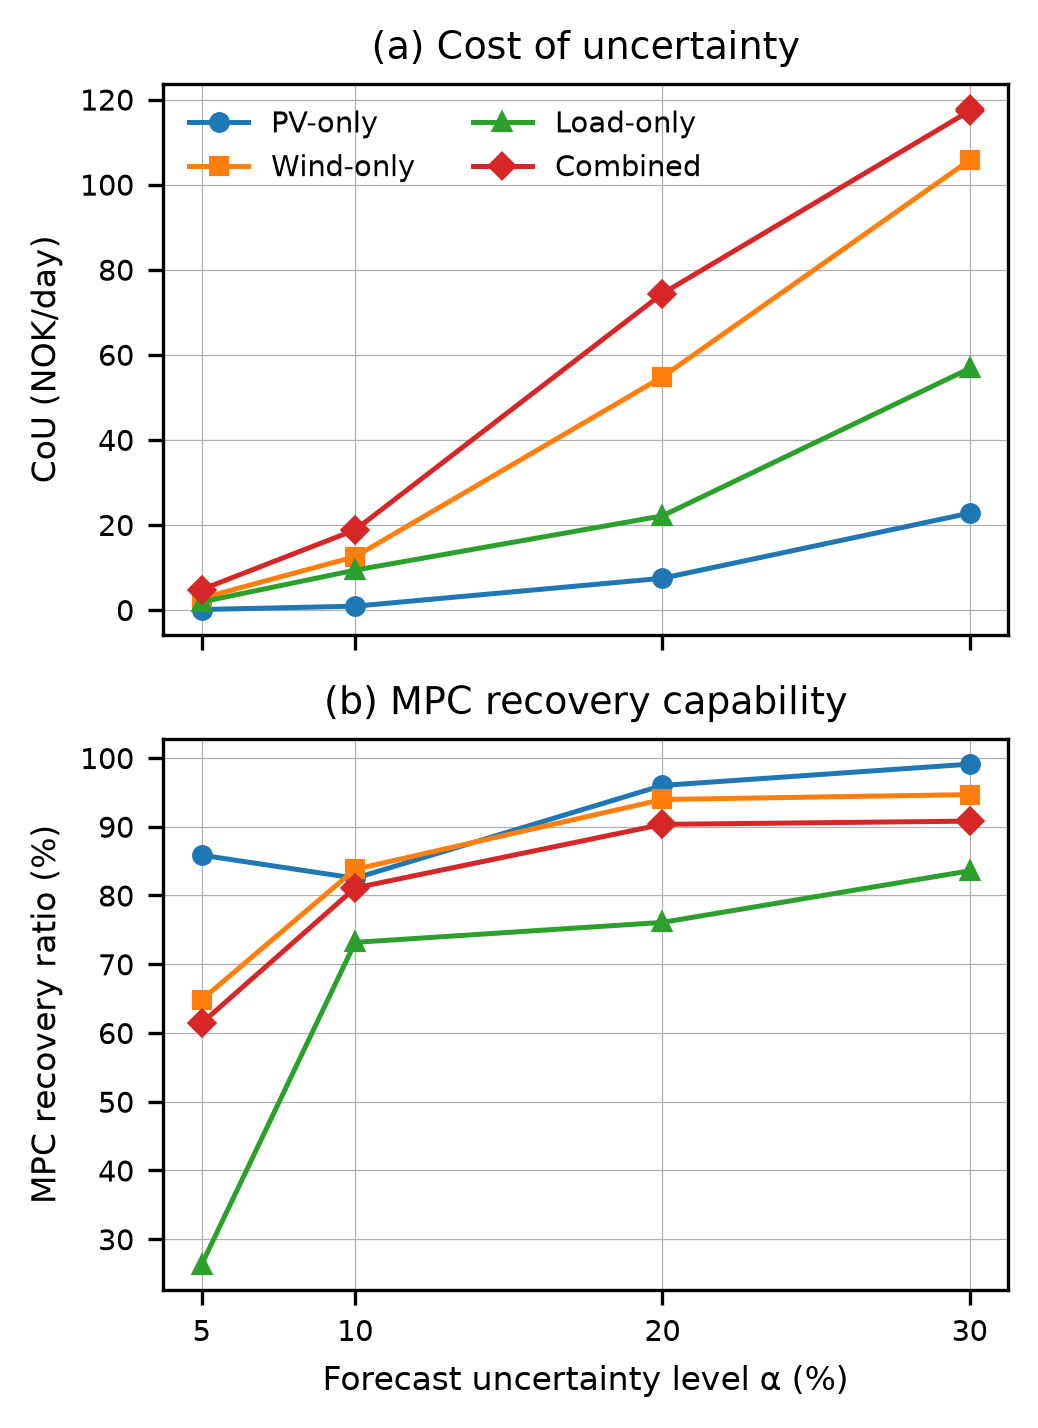

Saved PDF: forced_outage_results_v3\Fig5\Fig5_Source_Sensitivity.pdf
Saved PNG: forced_outage_results_v3\Fig5\Fig5_Source_Sensitivity.png


In [41]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


# ============================
# Prepare data
# ============================

fig_df = full_source_summary.copy()

# keep only required columns
plot_df = fig_df[
    [
        "source",
        "mode",
        "alpha",
        "cou_nok",
        "rr_percent"
    ]
].copy()


# use islanded case for source sensitivity
plot_df = plot_df[
    plot_df["mode"] == "IS"
]


# convert alpha to %
plot_df["alpha_pct"] = (
    plot_df["alpha"] * 100
)


# source order
source_order = [
    "PV-only",
    "Wind-only",
    "Load-only",
    "Combined"
]


# ============================
# Figure settings
# ============================

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})


fig, axes = plt.subplots(
    2,
    1,
    figsize=(3.5, 4.8),
    dpi=300,
    sharex=True
)


markers = [
    "o",
    "s",
    "^",
    "D"
]


# ============================
# (a) CoU
# ============================

ax = axes[0]

for src, marker in zip(source_order, markers):

    d = plot_df[
        plot_df["source"] == src
    ].sort_values("alpha_pct")

    ax.plot(
        d["alpha_pct"],
        d["cou_nok"],
        marker=marker,
        linewidth=1.2,
        markersize=4,
        label=src
    )


ax.set_ylabel(
    "CoU (NOK/day)"
)

ax.set_title(
    "(a) Cost of uncertainty"
)

ax.grid(
    True,
    linewidth=0.3
)


ax.legend(
    ncol=2,
    frameon=False,
    loc="upper left"
)


# ============================
# (b) RR
# ============================

ax = axes[1]


for src, marker in zip(source_order, markers):

    d = plot_df[
        plot_df["source"] == src
    ].sort_values("alpha_pct")

    ax.plot(
        d["alpha_pct"],
        d["rr_percent"],
        marker=marker,
        linewidth=1.2,
        markersize=4,
        label=src
    )


ax.set_xlabel(
    "Forecast uncertainty level α (%)"
)

ax.set_ylabel(
    "MPC recovery ratio (%)"
)


ax.set_title(
    "(b) MPC recovery capability"
)


ax.grid(
    True,
    linewidth=0.3
)


ax.set_xticks(
    [5,10,20,30]
)


plt.tight_layout()


# ============================
# Save
# ============================

OUT_DIR = Path(
    "forced_outage_results_v3/Fig5"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


pdf_path = OUT_DIR / "Fig5_Source_Sensitivity.pdf"
png_path = OUT_DIR / "Fig5_Source_Sensitivity.png"


fig.savefig(
    pdf_path,
    bbox_inches="tight"
)

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight"
)


plt.show()


print("Saved PDF:", pdf_path)
print("Saved PNG:", png_path)

   source mode  alpha_pct    cou_nok  rr_percent
  PV-only   IS          5   0.114316   85.868625
  PV-only   IS         10   0.899882   82.514186
  PV-only   IS         20   7.457750   96.006089
  PV-only   IS         30  22.764165   99.104555
Wind-only   IS          5   2.770898   64.818418
Wind-only   IS         10  12.545848   83.807187
Wind-only   IS         20  54.787340   93.963480
Wind-only   IS         30 105.737307   94.674571
Load-only   IS          5   1.896982   26.299722
Load-only   IS         10   9.373293   73.179236
Load-only   IS         20  22.125478   76.084461
Load-only   IS         30  56.786922   83.587485
 Combined   IS          5   4.812263   61.414573
 Combined   IS         10  18.836578   81.097454
 Combined   IS         20  74.377807   90.346537
 Combined   IS         30 117.769155   90.851943


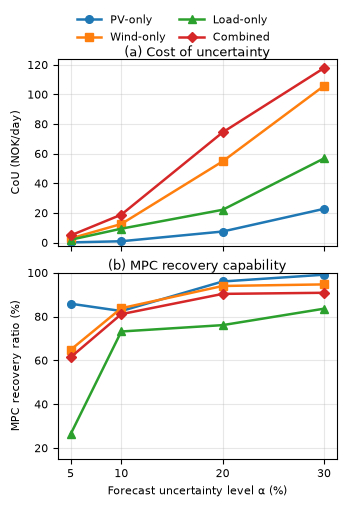

Saved PDF: forced_outage_results_v3\Fig5\Fig5\Fig5_Source_Sensitivity_Final.pdf
Saved PNG: forced_outage_results_v3\Fig5\Fig5\Fig5_Source_Sensitivity_Final.png


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# 1) Load source-sensitivity summary
# =========================================================

# যদি source_summary already memory-তে থাকে, সেটা use করবে
if "source_summary" in globals():
    ss = source_summary.copy()
else:
    summary_path = Path(
        r"E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Source_Sensitivity_FULL\source_sensitivity_det_sto_mpc_pf_summary.csv"
    )
    ss = pd.read_csv(summary_path)

# =========================================================
# 2) Clean / prepare
# =========================================================
ss["mode"] = ss["mode"].astype(str).str.upper().str.strip()
ss["source"] = ss["source"].astype(str).str.strip()
ss["alpha"] = ss["alpha"].astype(float)
ss["alpha_pct"] = (100 * ss["alpha"]).round().astype(int)

# যদি duplicate row থাকে, one row keep করবে
ss = ss.sort_values(["source", "mode", "alpha"])
ss = ss.drop_duplicates(subset=["source", "mode", "alpha_pct"], keep="last")

# শুধু Islanded (IS) case
plot_df = ss[ss["mode"] == "IS"].copy()

source_order = ["PV-only", "Wind-only", "Load-only", "Combined"]
alpha_order = [5, 10, 20, 30]

plot_df["source"] = pd.Categorical(
    plot_df["source"], categories=source_order, ordered=True
)
plot_df = plot_df.sort_values(["source", "alpha_pct"])

print(plot_df[[
    "source", "mode", "alpha_pct",
    "cou_nok", "rr_percent"
]].to_string(index=False))

# =========================================================
# 3) Figure style (IEEE single-column friendly)
# =========================================================
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
})

styles = {
    "PV-only":   {"marker": "o", "linewidth": 1.8, "markersize": 5.5},
    "Wind-only": {"marker": "s", "linewidth": 1.8, "markersize": 5.5},
    "Load-only": {"marker": "^", "linewidth": 1.8, "markersize": 5.5},
    "Combined":  {"marker": "D", "linewidth": 1.8, "markersize": 5.5},
}

fig, axes = plt.subplots(
    2, 1,
    figsize=(3.35, 4.6),   # IEEE single-column width approx
    sharex=True,
    constrained_layout=True
)

# =========================================================
# 4) Plot
# =========================================================
for src in source_order:
    d = plot_df[plot_df["source"] == src].copy()
    d = d.sort_values("alpha_pct")

    if d.empty:
        continue

    x = d["alpha_pct"].to_numpy()
    y1 = d["cou_nok"].to_numpy()
    y2 = d["rr_percent"].to_numpy()

    axes[0].plot(x, y1, label=src, **styles[src])
    axes[1].plot(x, y2, label=src, **styles[src])

# Titles
axes[0].set_title("(a) Cost of uncertainty", pad=2)
axes[1].set_title("(b) MPC recovery capability", pad=2)

# Labels
axes[0].set_ylabel("CoU (NOK/day)")
axes[1].set_ylabel("MPC recovery ratio (%)")
axes[1].set_xlabel("Forecast uncertainty level α (%)")

# Ticks / grid
for ax in axes:
    ax.set_xticks(alpha_order)
    ax.grid(True, alpha=0.30)

# Limits
axes[0].set_ylim(bottom=min(-2, plot_df["cou_nok"].min() - 1))

rr_min = max(0, np.floor(plot_df["rr_percent"].min() / 10) * 10 - 5)
rr_max = min(100, np.ceil(plot_df["rr_percent"].max() / 5) * 5 + 1)
axes[1].set_ylim(rr_min, rr_max)

# Shared legend (cleaner than inside subplot)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=2,
    frameon=False,
    columnspacing=1.2,
    handlelength=2.2
)

# =========================================================
# 5) Save
# =========================================================
if "OUT_DIR" in globals():
    fig5_dir = Path(OUT_DIR) / "Fig5"
else:
    fig5_dir = Path("forced_outage_results_v3") / "Fig5"

fig5_dir.mkdir(parents=True, exist_ok=True)

pdf_path = fig5_dir / "Fig5_Source_Sensitivity_Final.pdf"
png_path = fig5_dir / "Fig5_Source_Sensitivity_Final.png"

fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=600, bbox_inches="tight")

plt.show()

print("Saved PDF:", pdf_path)
print("Saved PNG:", png_path)

In [40]:
full_source_summary = build_full_source_summary(source_daily)

print("Summary rows =", len(full_source_summary))
display(full_source_summary)

Full source summary saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Source_Sensitivity_FULL\source_sensitivity_det_sto_mpc_pf_summary.csv
Summary rows = 40


,source,mode,alpha,det_mean_cost_nok,sto_mean_cost_nok,mpc_mean_cost_nok,pf_mean_cost_nok,cou_nok,cou_ci95_low,cou_ci95_high,...,mpc_mean_noncritical_eens_kwh,det_critical_interruption_probability,sto_critical_interruption_probability,mpc_critical_interruption_probability,mean_det_solve_time_s,mean_sto_solve_time_s,mean_mpc_total_solve_time_s,mean_mpc_final_soc_abs_deviation,max_mpc_final_soc_abs_deviation,max_mpc_final_energy_abs_deviation_kwh
0,Combined,GC,0.05,150.124597,150.117890,150.185610,150.116163,8.433807e-03,-1.687377e-03,1.855499e-02,...,0.001801,0.000000,0.000000,0.0,0.131774,2.167198,1.588185,0.000000e+00,0.000000e+00,0.000000e+00
1,Combined,GC,0.05,150.124615,150.117072,150.185610,150.116163,8.451387e-03,-1.669402e-03,1.857218e-02,...,0.001801,0.000000,0.000000,0.0,0.160037,2.240020,1.494697,0.000000e+00,0.000000e+00,0.000000e+00
2,Load-only,GC,0.05,150.120495,150.116351,150.170446,150.116163,4.332226e-03,-6.830566e-04,9.347509e-03,...,0.002205,0.000000,0.000000,0.0,0.100666,1.964405,1.541473,0.000000e+00,0.000000e+00,0.000000e+00
3,PV-only,GC,0.05,150.116163,150.116163,150.118517,150.116163,7.458601e-15,-1.438150e-16,1.506102e-14,...,0.000000,0.000000,0.000000,0.0,0.103347,1.894200,1.556502,0.000000e+00,0.000000e+00,0.000000e+00
4,Wind-only,GC,0.05,150.117398,150.117393,150.157233,150.116163,1.234697e-03,-3.351794e-04,2.804573e-03,...,0.000000,0.000000,0.000000,0.0,0.098889,1.992922,1.524850,0.000000e+00,0.000000e+00,0.000000e+00
5,Combined,GC,0.10,150.223765,150.191547,150.258391,150.116163,1.076022e-01,3.705462e-02,1.781498e-01,...,0.000000,0.000000,0.000000,0.0,0.099732,2.130752,1.589062,0.000000e+00,0.000000e+00,0.000000e+00
6,Combined,GC,0.10,150.223906,150.136899,150.258391,150.116163,1.077431e-01,3.720179e-02,1.782844e-01,...,0.000000,0.000000,0.000000,0.0,0.101486,2.423647,1.548427,0.000000e+00,0.000000e+00,0.000000e+00
7,Load-only,GC,0.10,150.168053,150.118154,150.212363,150.116163,5.189033e-02,7.617886e-03,9.616278e-02,...,0.000000,0.000000,0.000000,0.0,0.100710,2.185402,1.522157,0.000000e+00,0.000000e+00,0.000000e+00
8,PV-only,GC,0.10,150.116163,150.116247,150.118213,150.116163,7.514549e-15,-8.208881e-17,1.511119e-14,...,0.000000,0.000000,0.000000,0.0,0.099539,2.005834,1.565368,0.000000e+00,0.000000e+00,0.000000e+00
9,Wind-only,GC,0.10,150.186160,150.136219,150.198142,150.116163,6.999722e-02,9.269336e-03,1.307251e-01,...,0.000000,0.000000,0.000000,0.0,0.099951,2.140195,1.530921,0.000000e+00,0.000000e+00,0.000000e+00


In [21]:
print_key_source_tables(full_source_summary)


=== IS: source-wise CoU / SMR / RR / noncritical EENS ===
   source  alpha    cou_nok  cou_ci95_low  cou_ci95_high  smr_percent  rr_percent  det_mean_noncritical_eens_kwh  sto_mean_noncritical_eens_kwh  mpc_mean_noncritical_eens_kwh
 Combined   0.05   4.812263      2.401524       7.223001    89.582796   61.414573                       0.749512                       0.038594                       0.092928
Load-only   0.05   1.896982      0.704942       3.089022    81.348829   26.299722                       0.260632                       0.009296                       0.071586
  PV-only   0.05   0.114316     -0.019100       0.247732    29.598669   85.868625                       0.012132                       0.000000                       0.001060
Wind-only   0.05   2.770898      0.726692       4.815104    89.666787   64.818418                       0.354859                       0.035547                       0.030022
 Combined   0.10  18.836578     11.592523      26.080633    79.838

In [26]:
def make_source_paper_summary(source_daily):
    rows = []

    for (source, mode, alpha), g in source_daily.groupby(
        ["source", "mode", "alpha"]
    ):

        det = g["det_cost_nok"].to_numpy(float)
        sto = g["sto_cost_nok"].to_numpy(float)
        mpc = g["mpc_cost_nok"].to_numpy(float)
        pf  = g["pf_cost_nok"].to_numpy(float)

        # Cost of uncertainty
        cou_daily = det - pf

        # STO mitigation
        sto_save_daily = det - sto

        # MPC recovery
        mpc_save_daily = det - mpc

        # Direct STO-MPC difference
        sto_mpc_daily = sto - mpc


        cou, _, _ = paired_mean_ci(cou_daily)

        sto_save, sto_lo, sto_hi = paired_mean_ci(sto_save_daily)

        mpc_save, mpc_lo, mpc_hi = paired_mean_ci(mpc_save_daily)

        sto_mpc, sto_mpc_lo, sto_mpc_hi = paired_mean_ci(sto_mpc_daily)


        smr = (
            100 * sto_save / cou
            if abs(cou) > 1e-12 else np.nan
        )

        rr = (
            100 * mpc_save / cou
            if abs(cou) > 1e-12 else np.nan
        )


        rows.append({

            "source": source,
            "mode": mode,
            "alpha": alpha,

            # uncertainty exposure
            "cou_nok": cou,

            # STO
            "sto_savings_nok": sto_save,
            "sto_ci95_low": sto_lo,
            "sto_ci95_high": sto_hi,
            "SMR_percent": smr,

            # MPC
            "mpc_savings_nok": mpc_save,
            "mpc_ci95_low": mpc_lo,
            "mpc_ci95_high": mpc_hi,
            "RR_percent": rr,

            # direct comparison
            "sto_minus_mpc_nok": sto_mpc,
            "sto_minus_mpc_ci95_low": sto_mpc_lo,
            "sto_minus_mpc_ci95_high": sto_mpc_hi,


            # reliability
            "det_noncritical_eens_kwh":
                g["det_noncritical_eens_kwh"].mean(),

            "sto_noncritical_eens_kwh":
                g["sto_noncritical_eens_kwh"].mean(),

            "mpc_noncritical_eens_kwh":
                g["mpc_noncritical_eens_kwh"].mean(),

        })


    return (
        pd.DataFrame(rows)
        .sort_values(
            ["source", "mode", "alpha"]
        )
        .reset_index(drop=True)
    )

In [27]:
source_paper_table = make_source_paper_summary(source_daily)

display(source_paper_table)

,source,mode,alpha,cou_nok,sto_savings_nok,sto_ci95_low,sto_ci95_high,SMR_percent,mpc_savings_nok,mpc_ci95_low,mpc_ci95_high,RR_percent,sto_minus_mpc_nok,sto_minus_mpc_ci95_low,sto_minus_mpc_ci95_high,det_noncritical_eens_kwh,sto_noncritical_eens_kwh,mpc_noncritical_eens_kwh
0,Load-only,GC,0.05,4.332226e-03,4.144068e-03,-8.753519e-04,9.163487e-03,95.656764,-0.049951,-0.096321,-0.003580,-1153.000691,-0.054095,-0.100345,-0.007844,0.000000,0.000000,0.002205
1,Load-only,GC,0.10,5.189033e-02,4.989948e-02,5.720156e-03,9.407881e-02,96.163351,-0.044309,-0.120257,0.031638,-85.390591,-0.094209,-0.168622,-0.019796,0.000000,0.000000,0.000000
2,Load-only,GC,0.20,1.262253e-01,5.829839e-02,2.205822e-03,1.143910e-01,46.185982,-0.092148,-0.233076,0.048780,-73.002739,-0.150446,-0.284007,-0.016886,0.000000,0.000000,0.000000
3,Load-only,GC,0.30,4.954131e-01,-1.130835e-01,-7.131966e-01,4.870296e-01,-22.826097,-0.267580,-0.955057,0.419897,-54.011502,-0.154497,-1.211023,0.902030,0.000000,0.000000,0.003651
4,Load-only,IS,0.05,1.896982e+00,1.543173e+00,3.655117e-01,2.720834e+00,81.348829,0.498901,-0.769728,1.767530,26.299722,-1.044272,-1.617229,-0.471314,0.260632,0.009296,0.071586
5,Load-only,IS,0.10,9.373293e+00,7.111097e+00,3.762855e+00,1.045934e+01,75.865517,6.859304,3.208449,10.510160,73.179236,-0.251793,-1.807315,1.303729,1.139268,0.178996,0.106169
6,Load-only,IS,0.20,2.212548e+01,1.489896e+01,9.378296e+00,2.041963e+01,67.338482,16.834051,11.420468,22.247634,76.084461,1.935090,-0.983003,4.853183,2.492944,0.617272,0.218821
7,Load-only,IS,0.30,5.678692e+01,3.189284e+01,1.872094e+01,4.506474e+01,56.162300,47.466760,33.414287,61.519233,83.587485,15.573919,7.616868,23.530970,5.884814,1.301298,0.339876
8,PV-only,GC,0.05,7.458601e-15,-5.594825e-17,-1.666682e-16,5.477169e-17,NaN,-0.002354,-0.005358,0.000651,NaN,-0.002354,-0.005358,0.000651,0.000000,0.000000,0.000000
9,PV-only,GC,0.10,7.514549e-15,-8.435111e-05,-2.512795e-04,8.257725e-05,NaN,-0.002050,-0.003722,-0.000378,NaN,-0.001966,-0.003649,-0.000282,0.000000,0.000000,0.000000


In [28]:
source_paper_compact = source_paper_table[
    [
        "source",
        "mode",
        "alpha",

        "cou_nok",

        "SMR_percent",
        "RR_percent",

        "sto_savings_nok",
        "mpc_savings_nok",

        "det_noncritical_eens_kwh",
        "sto_noncritical_eens_kwh",
        "mpc_noncritical_eens_kwh",
    ]
]


print(
    source_paper_compact.to_string(index=False)
)

   source mode  alpha      cou_nok  SMR_percent   RR_percent  sto_savings_nok  mpc_savings_nok  det_noncritical_eens_kwh  sto_noncritical_eens_kwh  mpc_noncritical_eens_kwh
Load-only   GC   0.05 4.332226e-03    95.656764 -1153.000691     4.144068e-03        -0.049951                  0.000000                  0.000000                  0.002205
Load-only   GC   0.10 5.189033e-02    96.163351   -85.390591     4.989948e-02        -0.044309                  0.000000                  0.000000                  0.000000
Load-only   GC   0.20 1.262253e-01    46.185982   -73.002739     5.829839e-02        -0.092148                  0.000000                  0.000000                  0.000000
Load-only   GC   0.30 4.954131e-01   -22.826097   -54.011502    -1.130835e-01        -0.267580                  0.000000                  0.000000                  0.003651
Load-only   IS   0.05 1.896982e+00    81.348829    26.299722     1.543173e+00         0.498901                  0.260632               

In [16]:
print("Rows =", len(source_det_sto))

dup = source_det_sto.duplicated(
    subset=["date", "source", "mode", "alpha"]
).sum()

print("Duplicate cases =", dup)

print(
    "PF > DET violations =",
    int(((source_det_sto["pf_cost_nok"] - source_det_sto["det_cost_nok"]) > 1e-5).sum())
)

print(
    "PF > STO violations =",
    int(((source_det_sto["pf_cost_nok"] - source_det_sto["sto_cost_nok"]) > 1e-5).sum())
)

print(
    "Max PF - DET =",
    (source_det_sto["pf_cost_nok"] - source_det_sto["det_cost_nok"]).max()
)

print(
    "Max PF - STO =",
    (source_det_sto["pf_cost_nok"] - source_det_sto["sto_cost_nok"]).max()
)

print(
    "Max simultaneous buy/sell DET =",
    source_det_sto["det_max_simultaneous_buy_sell_kw"].max()
)

print(
    "Max simultaneous buy/sell STO =",
    source_det_sto["sto_max_simultaneous_buy_sell_kw"].max()
)

Rows = 3048
Duplicate cases = 0
PF > DET violations = 0
PF > STO violations = 0
Max PF - DET = 1.8189894035458565e-12
Max PF - STO = 1.8189894035458565e-12
Max simultaneous buy/sell DET = 0.0
Max simultaneous buy/sell STO = 0.0


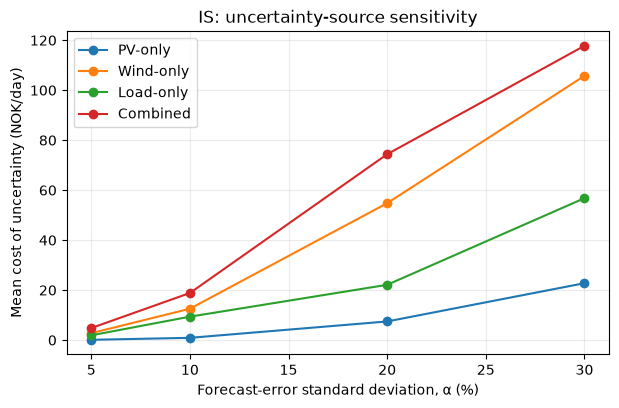

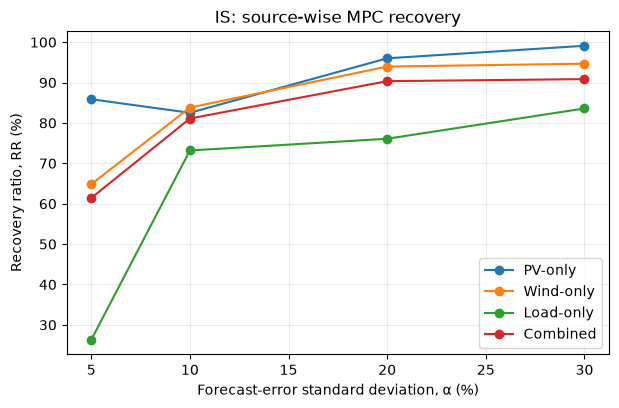

In [32]:
def plot_source_cou(full_summary, mode="IS"):
    g = full_summary[full_summary["mode"] == mode].copy()

    fig, ax = plt.subplots(figsize=(7.0, 4.2))
    for source in ALL_SOURCE_LABELS:
        x = g[g["source"] == source].sort_values("alpha")
        if len(x) == 0:
            continue
        ax.plot(
            x["alpha"] * 100,
            x["cou_nok"],
            marker="o",
            label=source,
        )

    ax.set_xlabel("Forecast-error standard deviation, α (%)")
    ax.set_ylabel("Mean cost of uncertainty (NOK/day)")
    ax.set_title(f"{mode}: uncertainty-source sensitivity")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()


def plot_source_rr(full_summary, mode="IS"):
    g = full_summary[full_summary["mode"] == mode].copy()

    fig, ax = plt.subplots(figsize=(7.0, 4.2))
    for source in ALL_SOURCE_LABELS:
        x = g[g["source"] == source].sort_values("alpha")
        if len(x) == 0:
            continue
        ax.plot(
            x["alpha"] * 100,
            x["rr_percent"],
            marker="o",
            label=source,
        )

    ax.set_xlabel("Forecast-error standard deviation, α (%)")
    ax.set_ylabel("Recovery ratio, RR (%)")
    ax.set_title(f"{mode}: source-wise MPC recovery")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()


# Run only after full_source_summary exists:
plot_source_cou(full_source_summary, mode="IS")
plot_source_rr(full_source_summary, mode="IS")